# Etape 6 Évaluation et Optimisation des modèles

1. Chargement des modèles sauvegardés

In [37]:
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

MODELS_DIR = "../models"

logreg = joblib.load(os.path.join(MODELS_DIR, "log_reg.pkl"))
dtree  = joblib.load(os.path.join(MODELS_DIR, "decision_tree.pkl"))
rf     = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))

import pandas as pd

train_df = pd.read_parquet("../data/models/train.parquet")
test_df  = pd.read_parquet("../data/models/test.parquet")

X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]


2. Évaluation des modèles de base

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # Probabilités seulement si dispo
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    # Si labels sont 0/1 -> pos_label=1, sinon pos_label="Yes"
    pos_label = 1 if y_test.unique().dtype in ["int64", "int32"] or set(y_test.unique()) == {0,1} else "Yes"
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=pos_label),
        "Recall": recall_score(y_test, y_pred, pos_label=pos_label),
        "F1": f1_score(y_test, y_pred, pos_label=pos_label),
    }
    
    if y_proba is not None:
        metrics["ROC AUC"] = roc_auc_score(y_test, y_proba)
    
    return metrics

# --- Comparaison des modèles ---
results = {}
results["Logistic Regression"] = evaluate_model(logreg, X_test, y_test)
results["Decision Tree"] = evaluate_model(dtree, X_test, y_test)
results["Random Forest"] = evaluate_model(rf, X_test, y_test)

results_df = pd.DataFrame(results).T
print(results_df)


                     Accuracy  Precision    Recall        F1   ROC AUC
Logistic Regression  0.806246   0.658307  0.561497  0.606061  0.841918
Decision Tree        0.798439   0.634731  0.566845  0.598870  0.830286
Random Forest        0.796309   0.646465  0.513369  0.572280  0.840162


3. Optimisation des hyperparamètres

on va faire un GridSearchCV pour chaque modèle.

Avec RandoForest:

In [29]:
# --- Grille d’hyperparamètres pour RandomForest ---
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# --- GridSearch sur l’ensemble d’entraînement ---
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",  # on optimise l'AUC
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

# --- Meilleurs hyperparamètres trouvés ---
print("Best params RF:", grid_search_rf.best_params_)
print("Best AUC (CV) RF:", grid_search_rf.best_score_)

# --- Évaluation finale sur le jeu de test ---
best_rf = grid_search_rf.best_estimator_

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred))
print("Final ROC AUC on Test:", roc_auc_score(y_test, y_proba))

# --- Sauvegarde du modèle optimisé ---
joblib.dump(best_rf, os.path.join(MODELS_DIR, "random_forest_optimized.pkl"))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params RF: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best AUC (CV) RF: 0.8470183803576757

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Final ROC AUC on Test: 0.8423454493786974


['../models\\random_forest_optimized.pkl']

Avec LogisticRegression:

In [30]:
param_grid = [
    # liblinear
    {"logreg__penalty": ["l1", "l2"],
     "logreg__C": [0.01, 0.1, 1, 10, 100],
     "logreg__solver": ["liblinear"],
     "logreg__max_iter": [100, 500, 1000]},
    
    # lbfgs
    {"logreg__penalty": ["l2", None],
     "logreg__C": [0.01, 0.1, 1, 10, 100],
     "logreg__solver": ["lbfgs"],
     "logreg__max_iter": [100, 500, 1000]},
    
    # saga
    {"logreg__penalty": ["l1", "l2", None],
     "logreg__C": [0.01, 0.1, 1, 10, 100],
     "logreg__solver": ["saga"],
     "logreg__max_iter": [100, 500, 1000]},
    
    # elasticnet avec saga (il faut l1_ratio)
    {"logreg__penalty": ["elasticnet"],
     "logreg__C": [0.01, 0.1, 1, 10, 100],
     "logreg__solver": ["saga"],
     "logreg__l1_ratio": [0.1, 0.5, 0.7, 0.9],
     "logreg__max_iter": [500, 1000]}
]


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=42))
])

grid_search_logreg = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_logreg.fit(X_train, y_train)

best_logreg = grid_search_logreg.best_estimator_
print("Best params Logistic Regression:", grid_search_logreg.best_params_)
print("Best AUC Logistic Regression:", grid_search_logreg.best_score_)

joblib.dump(best_logreg, os.path.join(MODELS_DIR, "logreg_optimized.pkl"))


Fitting 5 folds for each of 145 candidates, totalling 725 fits
Best params Logistic Regression: {'logreg__C': 100, 'logreg__max_iter': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'saga'}
Best AUC Logistic Regression: 0.8455444442080495


c:\Users\User\Downloads\projet3\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


['../models\\logreg_optimized.pkl']

Avec DecisionTreeClassifier:

In [31]:
from sklearn.model_selection import GridSearchCV


# Grille réaliste et efficace
param_grid = {
    "max_depth": [3, 5, 7, 10, 15],          # Limite la profondeur pour éviter l'overfitting
    "min_samples_split": [2, 5, 10, 20],     # Nombre minimum d'échantillons pour diviser un nœud
    "min_samples_leaf": [1, 2, 4, 10],       # Nombre minimum d'échantillons dans une feuille
    "criterion": ["gini", "entropy"]         # Critère de séparation
}

grid_search_dtree = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    scoring="roc_auc",   # On optimise l'AUC
    cv=5,                # 5-fold cross validation
    n_jobs=-1,           # utiliser tous les cœurs
    verbose=2
)

grid_search_dtree.fit(X_train, y_train)

best_dtree = grid_search_dtree.best_estimator_
print("Best params Decision Tree:", grid_search_dtree.best_params_)
print("Best AUC Decision Tree:", grid_search_dtree.best_score_)

joblib.dump(best_dtree, os.path.join(MODELS_DIR, "decision_tree_optimized.pkl"))


Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best params Decision Tree: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best AUC Decision Tree: 0.8252991046626457


['../models\\decision_tree_optimized.pkl']

Comparaison finale & justification

tableau avant vs après optimisation :

In [32]:
results_opt = {}
results_opt["Random Forest Optimized"] = evaluate_model(best_rf, X_test, y_test)
results_opt["Logistic Regression Optimized"] = evaluate_model(best_logreg, X_test, y_test)
results_opt["Decision Tree Optimized"] = evaluate_model(best_dtree, X_test, y_test)


final_results = pd.concat([results_df, pd.DataFrame(results_opt).T])
print(final_results)


                               Accuracy  Precision    Recall        F1  \
Logistic Regression            0.806246   0.658307  0.561497  0.606061   
Decision Tree                  0.798439   0.634731  0.566845  0.598870   
Random Forest                  0.796309   0.646465  0.513369  0.572280   
Random Forest Optimized        0.801987   0.663230  0.516043  0.580451   
Logistic Regression Optimized  0.804116   0.653125  0.558824  0.602305   
Decision Tree Optimized        0.798439   0.634731  0.566845  0.598870   

                                ROC AUC  
Logistic Regression            0.841918  
Decision Tree                  0.830286  
Random Forest                  0.840162  
Random Forest Optimized        0.842345  
Logistic Regression Optimized  0.841158  
Decision Tree Optimized        0.830286  


# Graphique comparatif des modèles pour visualiser leurs performances en termes de ROC AUC et F1 score :

In [ ]:
# Noms des modèles
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Random Forest Optimized",
    "Logistic Regression Optimized",
    "Decision Tree Optimized"
]

# F1 scores
f1_scores = [0.606061, 0.598870, 0.572280, 0.580451, 0.602305, 0.598870]

# ROC AUC scores
roc_auc_scores = [0.841918, 0.830286, 0.840162, 0.842345, 0.841158, 0.830286]

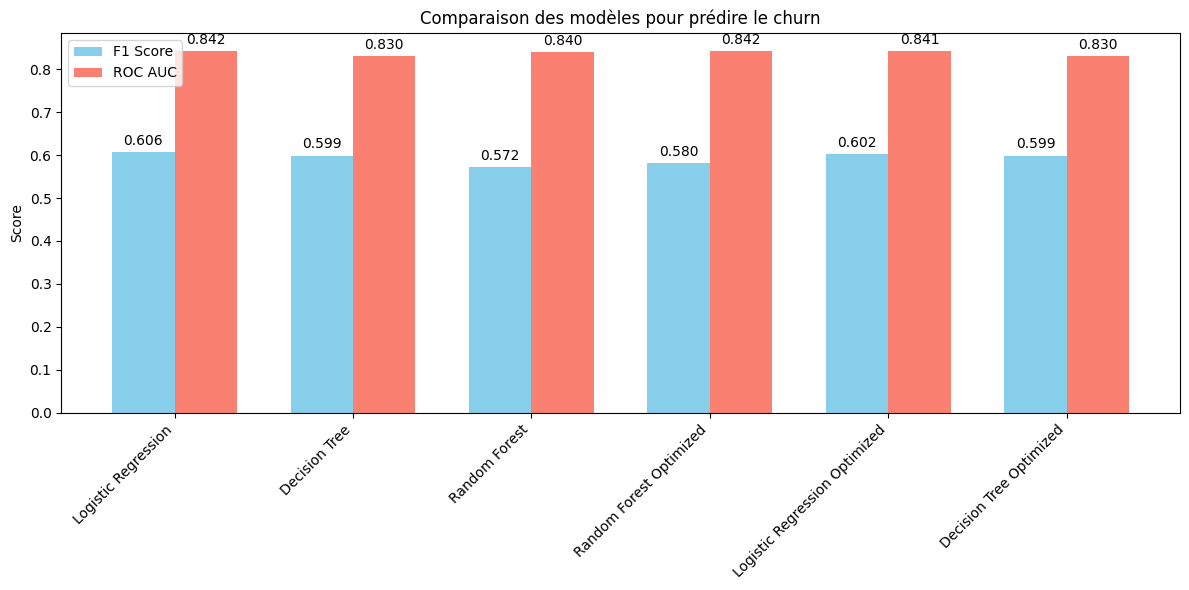

In [38]:
x = np.arange(len(models))  # positions des modèles
width = 0.35  # largeur des barres

fig, ax = plt.subplots(figsize=(12,6))

# Barres F1
bars1 = ax.bar(x - width/2, f1_scores, width, label='F1 Score', color='skyblue')

# Barres ROC AUC
bars2 = ax.bar(x + width/2, roc_auc_scores, width, label='ROC AUC', color='salmon')

# Titres et labels
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles pour prédire le churn')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()

# Ajouter les valeurs sur chaque barre
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Points clés à retenir

## Decision Tree

L’optimisation n’a pas amélioré les résultats.

AUC = 0.830, le plus faible parmi tous les modèles.

Conclusion : limité pour prédire le churn, sensible au surajustement.

## Logistic Regression

Stable et performant, AUC ≈ 0.842.

Optimisation a peu amélioré la précision et le F1, mais c’est un modèle fiable.

## Random Forest

Modèle robuste pour des patterns complexes.

Optimisé, il atteint la meilleure AUC (0.842345).

Cependant, Recall est plus faible (~0.516), donc il prédit moins bien les clients churners.

# Conclusion

Le meilleur modèle pour prédire le churn sur notre dataset est Random Forest Optimized, car il maximise l’AUC et capture mieux les patterns complexes.

Decision Tree seul n’est pas recommandé : performance inférieure et optimisation inefficace.

Logistic Regression reste une alternative simple et interprétable si on veux un modèle facile à expliquer, avec presque la même AUC.

Pour améliorer encore le Recall (identifier plus de churners), on pourrais explorer :

XGBoost / LightGBM

Ajustement du seuil de décision

Équilibrage des classes (class_weight='balanced' ou SMOTE)